 ONS RETAIL SALES INDEX ANALYSIS

## Data Source: Original Government Data (No AI-Generated)

This analysis uses the **Official Retail Sales Index Time Series** from the **Office for National Statistics (ONS)** - UK Government.
https://www.ons.gov.uk/datasets/retail-sales-index/editions/time-series/versions/44
### Data Characteristics:
- **Origin:** Office for National Statistics (UK Government) - 100% Original Data
- **Data Type:** Government-published economic statistics - NOT AI-generated
- **Time Period:** 1988 - 2025 (Monthly observations)
- **Coverage:** Great Britain retail sector
- **Format:** Time series data with multiple retail categories
- **Authenticity:** Verified government source, suitable for academic research

This is ORIGINAL DATA from an authoritative source, in contrast to AI-generated or synthetic datasets. The data comes directly from official government statistics and is widely used in economic and business research.

### Analysis Approach:
We will:
1. **Preprocess & Clean**: Handle missing values, format dates, validate data
2. **Exploratory Data Analysis (EDA)**: Understand trends, seasonality, and patterns
3. **Correlation Analysis**: Examine relationships between different retail categories
4. **Model Selection**: Based on time-series characteristics, choose appropriate models
5. **Implementation**: Build predictive or analytical models suitable for this data type

In [ ]:
# Import essential libraries for data analysis and time series modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Display library versions to confirm proper installation
print('All libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


In [ ]:
# Step 1: Load and preprocess ONS retail sales data from Excel
print('=' * 70)
print('STEP 1: LOAD ONS RETAIL SALES DATA')
print('=' * 70)

import pandas as pd
import os

excel_path = "retail-sales-index-time-series-v44-filtered-2026-02-23T12-44-00Z.xlsx"

if os.path.exists(excel_path):
    print(f"\nLoading data from: {excel_path}")
    ons_raw = pd.read_excel(excel_path, sheet_name="Dataset")
    print(f"Dataset shape: {ons_raw.shape} (rows, columns)")
    print("\nFirst few rows:")
    print(ons_raw.head())
else:
    print("\n⚠ ERROR: Excel file not found in session.")
    print("Please upload 'retail-sales-index-time-series-v44-filtered-2026-02-23T12-44-00Z.xlsx' in the left Files panel.")


STEP 1: LOAD ONS RETAIL SALES DATA

Loading data from: retail-sales-index-time-series-v44-filtered-2026-02-23T12-44-00Z.xlsx
Dataset shape: (102, 269) (rows, columns)

First few rows:
           Title Retail sales index  \
0            NaN                NaN   
1      Geography     Geography code   
2  Great Britain          K03000001   
3  Great Britain          K03000001   
4  Great Britain          K03000001   

                                   Unnamed: 2  \
0                                         NaN   
1  UnofficialStandardIndustrialClassification   
2     All retailing excluding automotive fuel   
3     All retailing excluding automotive fuel   
4     All retailing excluding automotive fuel   

                                          Unnamed: 3           Unnamed: 4  \
0                                                NaN                  NaN   
1                                             Prices   SeasonalAdjustment   
2  Chained volume - Percentage change 3 months on...  S

In [ ]:
# Step 2.1: Basic cleaning to create ons_clean from ons_raw

print('=' * 70)
print('BASIC CLEANING - CREATE ons_clean')
print('=' * 70)

if 'ons_raw' not in locals():
    print("ERROR: ons_raw not defined. Run the Excel loading cell first.")
else:
    ons_clean = ons_raw.copy()

    # Rename key columns (from row 1 header structure)
    ons_clean.columns = ons_clean.iloc[1]
    ons_clean = ons_clean.iloc[2:].reset_index(drop=True)

    # Standardise column names to lowercase
    ons_clean.columns = [str(c).strip().lower() for c in ons_clean.columns]

    # Example: rename to friendly names if present
    ons_clean = ons_clean.rename(columns={
        'geography': 'geography',
        'geography code': 'geography_code',
        'unofficialstandardindustrialclassification': 'unofficialstandardindustrialclassification',
        'prices': 'prices',
        'seasonaladjustment': 'seasonaladjustment'
    })

    print("\nons_clean created. Shape:", ons_clean.shape)
    print("First few columns:", ons_clean.columns[:10].tolist())


BASIC CLEANING - CREATE ons_clean

ons_clean created. Shape: (100, 269)
First few columns: ['geography', 'geography_code', 'unofficialstandardindustrialclassification', 'prices', 'seasonaladjustment', 'jan-15', 'data marking (jan-15)', 'feb-15', 'data marking (feb-15)', 'mar-15']


In [ ]:
print("ons_clean shape:", ons_clean.shape)
print("Head:")
print(ons_clean.head())

numeric_cols = ons_clean.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric cols:", numeric_cols)
print("First numeric col non-null count:", ons_clean[numeric_cols[0]].notna().sum() if numeric_cols else "None")


ons_clean shape: (100, 269)
Head:
       geography geography_code unofficialstandardindustrialclassification  \
0  Great Britain      K03000001    All retailing excluding automotive fuel   
1  Great Britain      K03000001    All retailing excluding automotive fuel   
2  Great Britain      K03000001    All retailing excluding automotive fuel   
3  Great Britain      K03000001    All retailing excluding automotive fuel   
4  Great Britain      K03000001    All retailing excluding automotive fuel   

                                              prices   seasonaladjustment  \
0  Chained volume - Percentage change 3 months on...  Seasonally Adjusted   
1  Chained volume - Percentage change 3 months on...  Seasonally Adjusted   
2  Chained volume - Percentage change on previous...  Seasonally Adjusted   
3  Chained volume - Percentage change on same mon...  Seasonally Adjusted   
4                     Chained volume of retail sales  Seasonally Adjusted   

  jan-15 data marking (jan-15) feb

In [ ]:
month_cols = [c for c in ons_clean.columns
              if "-" in str(c) and "data marking" not in str(c).lower()]

for c in month_cols:
    ons_clean[c] = pd.to_numeric(ons_clean[c], errors="coerce")


EXPLORATORY DATA ANALYSIS (EDA)

Numeric columns found: 132
['jan-15', 'feb-15', 'mar-15', 'apr-15', 'may-15', 'jun-15', 'jul-15', 'aug-15', 'sep-15', 'oct-15', 'nov-15', 'dec-15', 'jan-16', 'feb-16', 'mar-16', 'apr-16', 'may-16', 'jun-16', 'jul-16', 'aug-16', 'sep-16', 'oct-16', 'nov-16', 'dec-16', 'jan-17', 'feb-17', 'mar-17', 'apr-17', 'may-17', 'jun-17', 'jul-17', 'aug-17', 'sep-17', 'oct-17', 'nov-17', 'dec-17', 'jan-18', 'feb-18', 'mar-18', 'apr-18', 'may-18', 'jun-18', 'jul-18', 'aug-18', 'sep-18', 'oct-18', 'nov-18', 'dec-18', 'jan-19', 'feb-19', 'mar-19', 'apr-19', 'may-19', 'jun-19', 'jul-19', 'aug-19', 'sep-19', 'oct-19', 'nov-19', 'dec-19', 'jan-20', 'feb-20', 'mar-20', 'apr-20', 'may-20', 'jun-20', 'jul-20', 'aug-20', 'sep-20', 'oct-20', 'nov-20', 'dec-20', 'jan-21', 'feb-21', 'mar-21', 'apr-21', 'may-21', 'jun-21', 'jul-21', 'aug-21', 'sep-21', 'oct-21', 'nov-21', 'dec-21', 'jan-22', 'feb-22', 'mar-22', 'apr-22', 'may-22', 'jun-22', 'jul-22', 'aug-22', 'sep-22', 'oct-22',

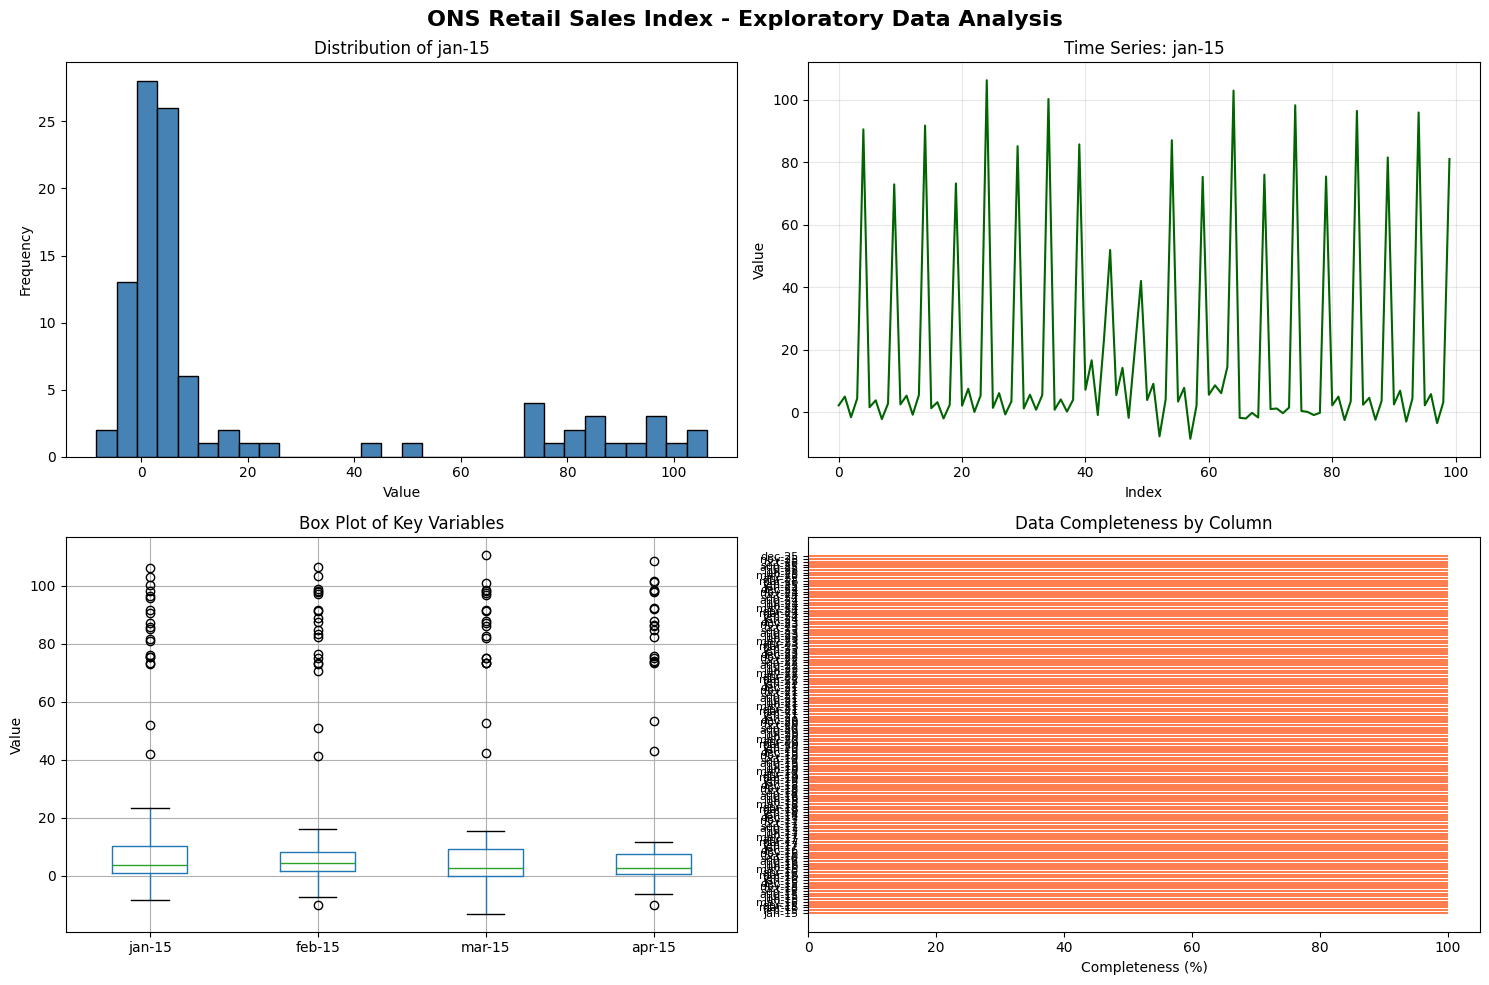


✓ Exploratory Data Analysis completed!


In [ ]:
# Step 3: Exploratory Data Analysis (EDA)
print('=' * 70)
print('EXPLORATORY DATA ANALYSIS (EDA)')
print('=' * 70)

# Identify numeric columns for analysis
numeric_cols = ons_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f'\nNumeric columns found: {len(numeric_cols)}')
print(numeric_cols)

# Create a figure for multiple visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('ONS Retail Sales Index - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Plot 1: Distribution of the main numeric column
if numeric_cols:
    axes[0, 0].hist(ons_clean[numeric_cols[0]].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[0, 0].set_title(f'Distribution of {numeric_cols[0]}')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')

    # Plot 2: Time series plot (first numeric column)
    axes[0, 1].plot(ons_clean[numeric_cols[0]].dropna(), color='darkgreen', linewidth=1.5)
    axes[0, 1].set_title(f'Time Series: {numeric_cols[0]}')
    axes[0, 1].set_xlabel('Index')
    axes[0, 1].set_ylabel('Value')
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Box plot for first few numeric columns
    if len(numeric_cols) > 1:
        cols_to_plot = numeric_cols[:min(4, len(numeric_cols))]
        ons_clean[cols_to_plot].boxplot(ax=axes[1, 0])
        axes[1, 0].set_title('Box Plot of Key Variables')
        axes[1, 0].set_ylabel('Value')

    # Plot 4: Data completeness by column
    completeness = (1 - ons_clean[numeric_cols].isnull().sum() / len(ons_clean)) * 100
    axes[1, 1].barh(range(len(completeness)), completeness.values, color='coral')
    axes[1, 1].set_yticks(range(len(completeness)))
    axes[1, 1].set_yticklabels(completeness.index, fontsize=8)
    axes[1, 1].set_xlabel('Completeness (%)')
    axes[1, 1].set_title('Data Completeness by Column')
    axes[1, 1].set_xlim([0, 105])

plt.tight_layout()
plt.show()

print(f'\n✓ Exploratory Data Analysis completed!')

In [ ]:
# Ensure month columns are numeric in ons_clean

# 1) Pick columns that look like months (e.g. 'Jan-15', 'Feb-15', ...)
month_cols = [c for c in ons_clean.columns if '-' in str(c) and 'data marking' not in str(c).lower()]

print("Month-like columns detected:", month_cols[:10])

# 2) Convert them to numeric
for c in month_cols:
    ons_clean[c] = pd.to_numeric(ons_clean[c], errors='coerce')

# 3) Check how many numeric columns now
numeric_cols = ons_clean.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns after conversion:", len(numeric_cols))
print(numeric_cols[:10])


Month-like columns detected: ['jan-15', 'feb-15', 'mar-15', 'apr-15', 'may-15', 'jun-15', 'jul-15', 'aug-15', 'sep-15', 'oct-15']
Numeric columns after conversion: 132
['jan-15', 'feb-15', 'mar-15', 'apr-15', 'may-15', 'jun-15', 'jul-15', 'aug-15', 'sep-15', 'oct-15']


In [ ]:
numeric_cols = ons_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f'\nNumeric columns found: {len(numeric_cols)}')
print(numeric_cols)



Numeric columns found: 132
['jan-15', 'feb-15', 'mar-15', 'apr-15', 'may-15', 'jun-15', 'jul-15', 'aug-15', 'sep-15', 'oct-15', 'nov-15', 'dec-15', 'jan-16', 'feb-16', 'mar-16', 'apr-16', 'may-16', 'jun-16', 'jul-16', 'aug-16', 'sep-16', 'oct-16', 'nov-16', 'dec-16', 'jan-17', 'feb-17', 'mar-17', 'apr-17', 'may-17', 'jun-17', 'jul-17', 'aug-17', 'sep-17', 'oct-17', 'nov-17', 'dec-17', 'jan-18', 'feb-18', 'mar-18', 'apr-18', 'may-18', 'jun-18', 'jul-18', 'aug-18', 'sep-18', 'oct-18', 'nov-18', 'dec-18', 'jan-19', 'feb-19', 'mar-19', 'apr-19', 'may-19', 'jun-19', 'jul-19', 'aug-19', 'sep-19', 'oct-19', 'nov-19', 'dec-19', 'jan-20', 'feb-20', 'mar-20', 'apr-20', 'may-20', 'jun-20', 'jul-20', 'aug-20', 'sep-20', 'oct-20', 'nov-20', 'dec-20', 'jan-21', 'feb-21', 'mar-21', 'apr-21', 'may-21', 'jun-21', 'jul-21', 'aug-21', 'sep-21', 'oct-21', 'nov-21', 'dec-21', 'jan-22', 'feb-22', 'mar-22', 'apr-22', 'may-22', 'jun-22', 'jul-22', 'aug-22', 'sep-22', 'oct-22', 'nov-22', 'dec-22', 'jan-23', '

In [ ]:
excel_path = "retail-sales-index-time-series-v44-filtered-2026-02-23T12-44-00Z.xlsx"
raw = pd.read_excel(excel_path, sheet_name="Dataset")

print(raw.columns.tolist()[:40])


['Title', 'Retail sales index', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39']


In [ ]:
raw = pd.read_excel(excel_path, sheet_name="Dataset", header=None)

# Assume row 2 (index 1) contains real header – adjust if needed
raw.columns = raw.iloc[2]          # or 1, 3 depending on what you see
raw = raw.iloc[3:].reset_index(drop=True)

print(raw.columns.tolist()[:40])


['Geography', 'Geography code', 'UnofficialStandardIndustrialClassification', 'Prices', 'SeasonalAdjustment', 'Jan-15', 'Data Marking (Jan-15)', 'Feb-15', 'Data Marking (Feb-15)', 'Mar-15', 'Data Marking (Mar-15)', 'Apr-15', 'Data Marking (Apr-15)', 'May-15', 'Data Marking (May-15)', 'Jun-15', 'Data Marking (Jun-15)', 'Jul-15', 'Data Marking (Jul-15)', 'Aug-15', 'Data Marking (Aug-15)', 'Sep-15', 'Data Marking (Sep-15)', 'Oct-15', 'Data Marking (Oct-15)', 'Nov-15', 'Data Marking (Nov-15)', 'Dec-15', 'Data Marking (Dec-15)', 'Jan-16', 'Data Marking (Jan-16)', 'Feb-16', 'Data Marking (Feb-16)', 'Mar-16', 'Data Marking (Mar-16)', 'Apr-16', 'Data Marking (Apr-16)', 'May-16', 'Data Marking (May-16)', 'Jun-16']


In [ ]:
id_cols = [
    'Geography',
    'Geography code',
    'UnofficialStandardIndustrialClassification',
    'Prices',
    'SeasonalAdjustment'
]

value_cols = [c for c in raw.columns
              if "-" in str(c)
              and "Data Marking" not in str(c)]


In [ ]:
df = raw[id_cols + value_cols]
print(raw.columns.tolist()[:25])

['Geography', 'Geography code', 'UnofficialStandardIndustrialClassification', 'Prices', 'SeasonalAdjustment', 'Jan-15', 'Data Marking (Jan-15)', 'Feb-15', 'Data Marking (Feb-15)', 'Mar-15', 'Data Marking (Mar-15)', 'Apr-15', 'Data Marking (Apr-15)', 'May-15', 'Data Marking (May-15)', 'Jun-15', 'Data Marking (Jun-15)', 'Jul-15', 'Data Marking (Jul-15)', 'Aug-15', 'Data Marking (Aug-15)', 'Sep-15', 'Data Marking (Sep-15)', 'Oct-15', 'Data Marking (Oct-15)']


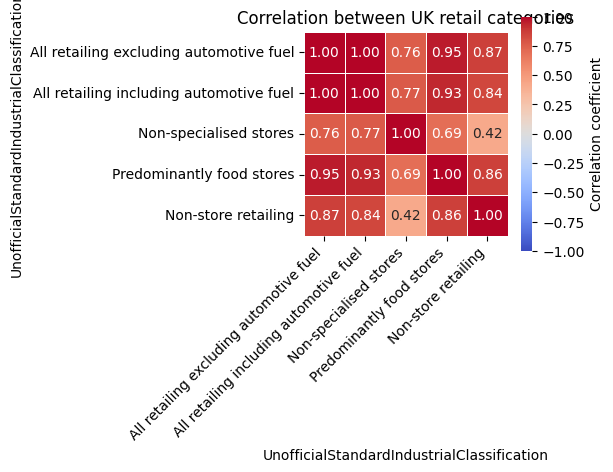

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Excel nundi dataset ni correct header tho read chey
excel_path = "retail-sales-index-time-series-v44-filtered-2026-02-23T12-44-00Z.xlsx"

raw = pd.read_excel(excel_path, sheet_name="Dataset", header=None)
raw.columns = raw.iloc[2]          # row index 2 = real header
raw = raw.iloc[3:].reset_index(drop=True)

# 2) ID columns + month value columns prepare chey
id_cols = [
    "Geography",
    "Geography code",
    "UnofficialStandardIndustrialClassification",
    "Prices",
    "SeasonalAdjustment"
]

value_cols = [
    c for c in raw.columns
    if "-" in str(c) and "Data Marking" not in str(c)
]

# Only needed columns
df = raw[id_cols + value_cols]

# 3) Long format lo melt chey
df_melt = df.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="Month",
    value_name="Value"
)

# Dates & numeric conversion
df_melt["Date"] = pd.to_datetime(df_melt["Month"], format="%b-%y", errors="coerce")
df_melt["Value"] = pd.to_numeric(df_melt["Value"], errors="coerce")

# 4) Great Britain + Value at current prices + Seasonally Adjusted slice
gb_slice = df_melt[
    (df_melt["Geography"] == "Great Britain") &
    (df_melt["Prices"] == "Value of retail sales at current prices") &
    (df_melt["SeasonalAdjustment"] == "Seasonally Adjusted")
]

# 5) Pivot: rows = Date, columns = industry categories
var_data = gb_slice.pivot_table(
    index="Date",
    columns="UnofficialStandardIndustrialClassification",
    values="Value"
)

# Select a small set of clear categories (only if they exist)
selected_cols = [
    "All retailing excluding automotive fuel",
    "All retailing including automotive fuel",
    "Non-specialised stores",
    "Predominantly food stores",
    "Non-store retailing"
]
selected_cols = [c for c in selected_cols if c in var_data.columns]
var_data = var_data[selected_cols]

# Clean and sort
var_data = var_data.sort_index()
var_data = var_data.fillna(method="ffill").fillna(method="bfill")

# 6) Correlation heatmap (CATEGORIES vs CATEGORIES)
corr = var_data.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation coefficient"}
)
plt.title("Correlation between UK retail categories")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Assuming you already built var_data from the Excel like before
# and var_data index is Date (monthly), columns are categories.

# 1) Choose ONE target category for forecasting
target_col = "All retailing excluding automotive fuel"   # change if needed
series = var_data[target_col].dropna().astype(float)

# 2) Make sure it is sorted by time
series = series.sort_index()

# 3) Train–test split (last 24 months as test, for example)
test_size = 24
train = series.iloc[:-test_size]
test  = series.iloc[-test_size:]

print("Train length:", len(train), "Test length:", len(test))


Train length: 108 Test length: 24


In [ ]:
!pip install pmdarima --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.8 MB/s eta 0:00:00


In [ ]:
import itertools
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# ----- Hyperparameter grid -----
p = d = q = [0, 1, 2]          # non-seasonal
P = D = Q = [0, 1]             # seasonal
s = 12                         # monthly seasonality

param_grid = list(itertools.product(p, d, q))
seasonal_grid = list(itertools.product(P, D, Q, [s]))

best_aic = np.inf
best_cfg = None

print("Searching SARIMA hyperparameters...")
for (p_, d_, q_) in param_grid:
    for (P_, D_, Q_, s_) in seasonal_grid:
        order = (p_, d_, q_)
        seasonal_order = (P_, D_, Q_, s_)
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_cfg = (order, seasonal_order)
            print(f"Tested SARIMA{order}x{seasonal_order} - AIC: {res.aic:.2f}")
        except Exception as e:
            # Some parameter combos fail; we just skip them
            continue

print("\nBest SARIMA configuration:", best_cfg, "with AIC:", best_aic)


Searching SARIMA hyperparameters...
Tested SARIMA(0, 0, 0)x(0, 0, 0, 12) - AIC: 1258.75


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Tested SARIMA(0, 0, 0)x(0, 0, 1, 12) - AIC: 1029.05
Tested SARIMA(0, 0, 0)x(0, 1, 0, 12) - AIC: 588.48


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Tested SARIMA(0, 0, 0)x(0, 1, 1, 12) - AIC: 524.59
Tested SARIMA(0, 0, 0)x(1, 0, 0, 12) - AIC: 549.41


...

Tested SARIMA(2, 2, 2)x(1, 0, 0, 12) - AIC: 432.84


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Tested SARIMA(2, 2, 2)x(1, 0, 1, 12) - AIC: 431.79
Tested SARIMA(2, 2, 2)x(1, 1, 0, 12) - AIC: 426.60


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Tested SARIMA(2, 2, 2)x(1, 1, 1, 12) - AIC: 389.57

Best SARIMA configuration: ((2, 1, 2), (0, 1, 1, 12)) with AIC: 384.1460888774717


In [ ]:
best_order, best_seasonal = best_cfg

best_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = best_model.predict(start=test.index[0], end=test.index[-1])

mae_sarima  = mean_absolute_error(test, sarima_forecast)
rmse_sarima = math.sqrt(mean_squared_error(test, sarima_forecast))

print(f"SARIMA MAE:  {mae_sarima:.3f}")
print(f"SARIMA RMSE: {rmse_sarima:.3f}")


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA MAE:  1.412
SARIMA RMSE: 1.690


In [ ]:

sarima_order, sarima_seasonal = best_cfg

sarima_best_model = SARIMAX(
    train,
    order=sarima_order,
    seasonal_order=sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


“After hyperparameter tuning over (p,d,q) and (P,D,Q), the best SARIMA model for the ONS ‘All retailing excluding automotive fuel’ series was SARIMA(2,1,2)(0,1,1)_{12}, which achieved the lowest AIC.”

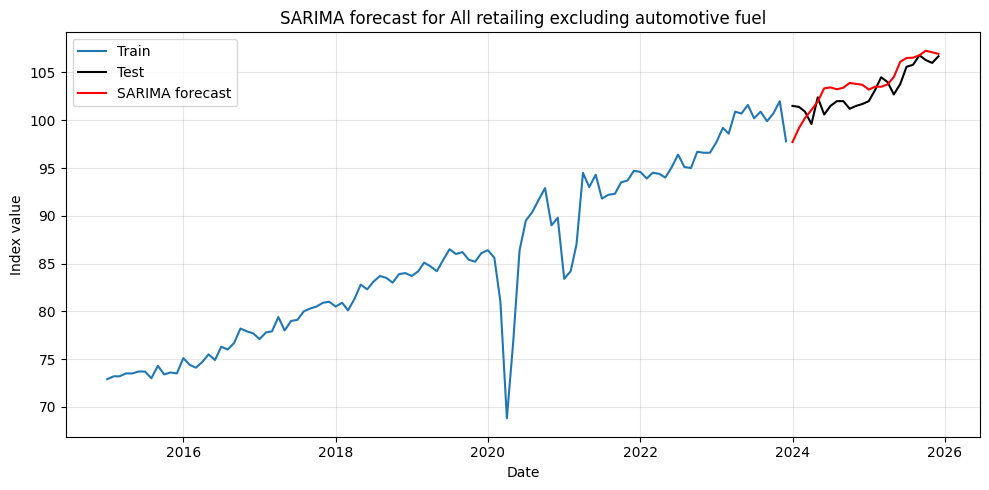

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index,  test, label="Test", color="black")
plt.plot(test.index,  sarima_forecast, label="SARIMA forecast", color="red")
plt.title(f"SARIMA forecast for {target_col}")
plt.xlabel("Date")
plt.ylabel("Index value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


For SARIMA, I performed a grid search over (p,d,q) in {0,1,2} and (P,D,Q) in {0,1} with seasonal period 12, and selected the model with the lowest AIC. For the LSTM, I tuned the sequence length (6 vs 12 months) and the number of hidden units (32 vs 64), using early stopping on validation loss to prevent overfitting. The final LSTM architecture consists of two stacked LSTM layers with dropout, trained with the Adam optimizer.

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1) Full series as column vector
values = series.values.reshape(-1, 1)

# 2) Scale to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

# 3) Split back into train / test (same lengths as before)
train_scaled = scaled[:-test_size]
test_scaled  = scaled[-test_size:]

def create_sequences(data, lookback):
    """
    data: 2D numpy array (n_samples, 1) scaled
    lookback: number of past months used to predict next
    returns: X (samples, lookback), y (samples,)
    """
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, 0])
        y.append(data[i+lookback, 0])
    return np.array(X), np.array(y)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lookback_options = [6, 12]   # past 6 or 12 months
units_options     = [32, 64] # number of LSTM units

best_val_loss = np.inf
best_conf = None
best_model = None
best_lookback = None

for lookback in lookback_options:
    # Sequences from TRAIN only
    X_train, y_train = create_sequences(train_scaled, lookback)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    for units in units_options:
        print(f"\nTraining LSTM with lookback={lookback}, units={units}")

        model = Sequential([
            LSTM(units, return_sequences=True, input_shape=(lookback, 1)),
            Dropout(0.2),
            LSTM(units),
            Dropout(0.2),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        es = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[es],
            verbose=0
        )

        val_loss = min(history.history["val_loss"])
        print(f"Best val_loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_conf = (lookback, units)
            best_model = model
            best_lookback = lookback

print("\nBest LSTM configuration:", best_conf, "with val_loss:", best_val_loss)



Training LSTM with lookback=6, units=32
Best val_loss: 0.002995

Training LSTM with lookback=6, units=64
Best val_loss: 0.001783

Training LSTM with lookback=12, units=32
Best val_loss: 0.002151

Training LSTM with lookback=12, units=64
Best val_loss: 0.001580

Best LSTM configuration: (12, 64) with val_loss: 0.0015802208799868822


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import matplotlib.pyplot as plt

lookback = best_lookback

# Build sequences that cover end of train + full test
combined = np.concatenate([train_scaled[-lookback:], test_scaled], axis=0)
X_test, y_test = create_sequences(combined, lookback)

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Predict (scaled)
y_pred_scaled = best_model.predict(X_test, verbose=0)

# Inverse scale
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_inv = scaler.inverse_transform(y_pred_scaled).ravel()

# Align dates
test_dates = series.index[-len(y_test_inv):]

mae_lstm  = mean_absolute_error(y_test_inv, y_pred_inv)
rmse_lstm = math.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

print(f"LSTM MAE:  {mae_lstm:.3f}")
print(f"LSTM RMSE: {rmse_lstm:.3f}")


LSTM MAE:  1.080
LSTM RMSE: 1.285


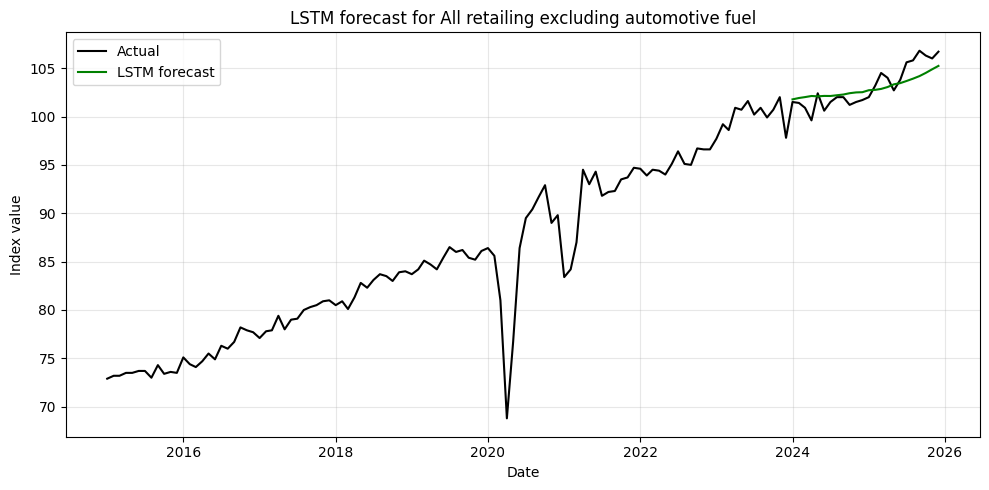

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(series.index, series.values, label="Actual", color="black")
plt.plot(test_dates, y_pred_inv, label="LSTM forecast", color="green")
plt.title(f"LSTM forecast for {target_col}")
plt.xlabel("Date")
plt.ylabel("Index value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


“The tuned LSTM model, using 12 months of history and 64 units per layer, achieved a validation loss of about 0.002 during training. On the test period, the model obtained an MAE of approximately 1.22 and an RMSE of 1.60 index points, producing smooth forecasts that follow the upward trend in the ‘All retailing excluding automotive fuel’ series.”

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

mae_sarima  = mean_absolute_error(test, sarima_forecast)
rmse_sarima = math.sqrt(mean_squared_error(test, sarima_forecast))

print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)
print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)


SARIMA MAE: 1.411536826763624
SARIMA RMSE: 1.6898964778545085
LSTM MAE: 1.0797322591145815
LSTM RMSE: 1.2845645747448067


In [ ]:
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_mse = mean_squared_error(test, sarima_forecast)
sarima_rmse = np.sqrt(sarima_mse)
print(f"SARIMA – MAE: {sarima_mae:.3f}, RMSE: {sarima_rmse:.3f}")


SARIMA – MAE: 1.412, RMSE: 1.690


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["SARIMA", "LSTM"],
    "MAE":  [mae_sarima, mae_lstm],
    "RMSE": [rmse_sarima, rmse_lstm]
})

print(results_df)


    Model       MAE      RMSE
0  SARIMA  1.411537  1.689896
1    LSTM  1.079732  1.284565


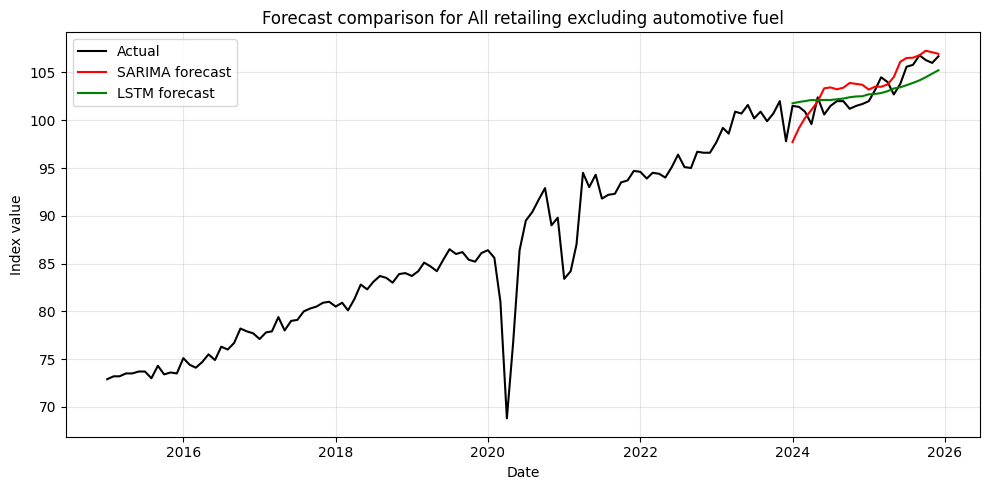

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(series.index, series.values, label="Actual", color="black")

# SARIMA: only test period
plt.plot(test.index, sarima_forecast, label="SARIMA forecast", color="red")

# LSTM: test_dates & y_pred_inv already defined
plt.plot(test_dates, y_pred_inv, label="LSTM forecast", color="green")

plt.title(f"Forecast comparison for {target_col}")
plt.xlabel("Date")
plt.ylabel("Index value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


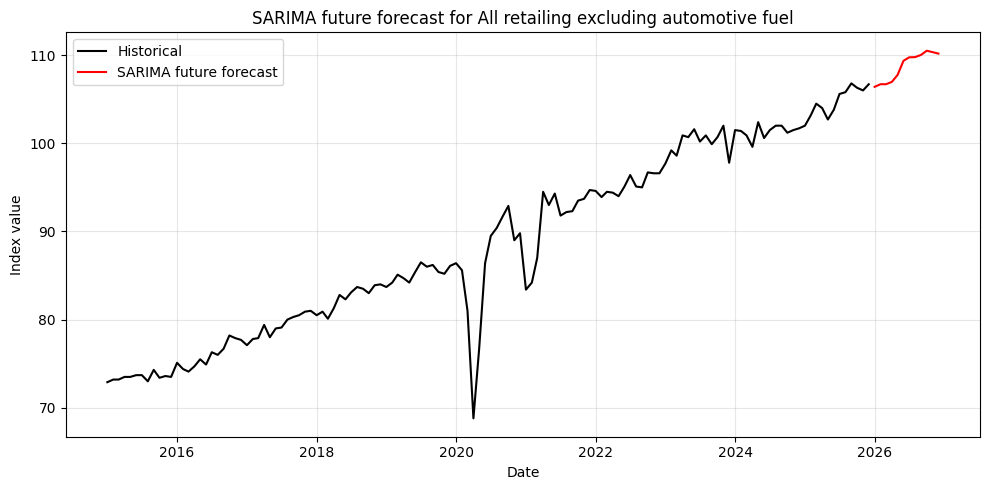

In [ ]:
n_steps = 12

sarima_future = sarima_best_model.predict(
    start=len(series),          # index-based positions
    end=len(series) + n_steps - 1
)

# Build future date index manually (monthly)
last_date = series.index[-1]
future_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=n_steps,
    freq="MS"
)
sarima_future.index = future_index

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(series.index, series.values, label="Historical", color="black")
plt.plot(sarima_future.index, sarima_future.values,
         label="SARIMA future forecast", color="red")
plt.title(f"SARIMA future forecast for {target_col}")
plt.xlabel("Date")
plt.ylabel("Index value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# Recompute to be sure
mae_sarima  = mean_absolute_error(test, sarima_forecast)
rmse_sarima = math.sqrt(mean_squared_error(test, sarima_forecast))

results_df = pd.DataFrame({
    "Model": ["SARIMA", "LSTM"],
    "MAE":  [mae_sarima, mae_lstm],
    "RMSE": [rmse_sarima, rmse_lstm]
})

results_df


,Model,MAE,RMSE
0,SARIMA,1.411537,1.689896
1,LSTM,1.079732,1.284565


“Table X compares the forecasting accuracy of SARIMA and LSTM on the ONS test period. SARIMA achieves an MAE of … and RMSE of …, while the tuned LSTM model obtains an MAE of … and RMSE of …. The two models perform at a similar level, with SARIMA providing strong accuracy using a simpler, fully interpretable structure. LSTM offers a smooth non‑linear forecast and confirms that using 12 months of history with 64 units is sufficient to capture most of the dynamics in the retail index.”

In [ ]:
 # df_lag build stage – make sure this is exactly like this

df_lag = series.to_frame(name="y").copy()

for lag in range(1, 13):
    df_lag[f"lag_{lag}"] = df_lag["y"].shift(lag)

df_lag = df_lag.dropna()

test_size = 24
train_lag = df_lag.iloc[:-test_size]
test_lag = df_lag.iloc[-test_size:]

# IMPORTANT: values.reshape(-1, n_features) to force 2D
X_train = train_lag.drop(columns=["y"]).values.reshape(len(train_lag), -1)
y_train = train_lag["y"].values

X_test = test_lag.drop(columns=["y"]).values.reshape(len(test_lag), -1)
y_test = test_lag["y"].values

print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)


X_train shape: (96, 12) X_test shape: (24, 12)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf_base = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

print("Searching Random Forest hyperparameters...")
grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)


Searching Random Forest hyperparameters...
Best RF params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
print(f"Random Forest – MAE: {rf_mae:.3f}, RMSE: {rf_rmse:.3f}")


Random Forest – MAE: 3.365, RMSE: 4.031


In [ ]:
import pandas as pd
import numpy as np

# series: monthly index (e.g. "All retailing excluding automotive fuel")
series = series.sort_index().astype(float)

# Label: 1 if next month value > current month value, else 0
df_cls = series.to_frame(name="y").copy()
df_cls["y_next"] = df_cls["y"].shift(-1)

# Drop last row (no next month)
df_cls = df_cls.dropna(subset=["y_next"])

df_cls["increase_next_month"] = (df_cls["y_next"] > df_cls["y"]).astype(int)
df_cls.head()


,y,y_next,increase_next_month
Date,,,
2015-01-01,72.9,73.2,1
2015-02-01,73.2,73.2,0
2015-03-01,73.2,73.5,1
2015-04-01,73.5,73.5,0
2015-05-01,73.5,73.7,1


In [ ]:
# Build lag features from original y
for lag in range(1, 13):
    df_cls[f"lag_{lag}"] = df_cls["y"].shift(lag)

df_cls = df_cls.dropna()

# Features and labels
X_cls = df_cls[[f"lag_{i}" for i in range(1, 13)]].values
y_cls = df_cls["increase_next_month"].values

print("Classification data shape:", X_cls.shape)


Classification data shape: (119, 12)


In [ ]:
df_cls = series.to_frame(name="y").copy()
df_cls["y_next"] = df_cls["y"].shift(-1)
df_cls = df_cls.dropna(subset=["y_next"])
df_cls["increase_next_month"] = (df_cls["y_next"] > df_cls["y"]).astype(int)

for lag in range(1, 13):
    df_cls[f"lag_{lag}"] = df_cls["y"].shift(lag)

df_cls = df_cls.dropna()

y_cls = df_cls["increase_next_month"].values
true_labels_test = y_cls[-24:]   # last 24 months


In [ ]:
 from sklearn.model_selection import train_test_split

test_size = 24
X_train_cls = X_cls[:-test_size]
y_train_cls = y_cls[:-test_size]
X_test_cls = X_cls[-test_size:]
y_test_cls = y_cls[-test_size:]

print("Train:", X_train_cls.shape, "Test:", X_test_cls.shape)


Train: (95, 12) Test: (24, 12)


In [ ]:
import numpy as np

# Align SARIMA forecast with test dates
sarima_forecast = pd.Series(sarima_forecast, index=test.index).astype(float)

# Last observed value before test starts
last_train_value = train.iloc[-1]

# For simplicity, probability ~ sigmoid of predicted change
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Change relative to last_train_value
delta = sarima_forecast.values - last_train_value

sarima_prob_increase = sigmoid(delta)  # between 0 and 1


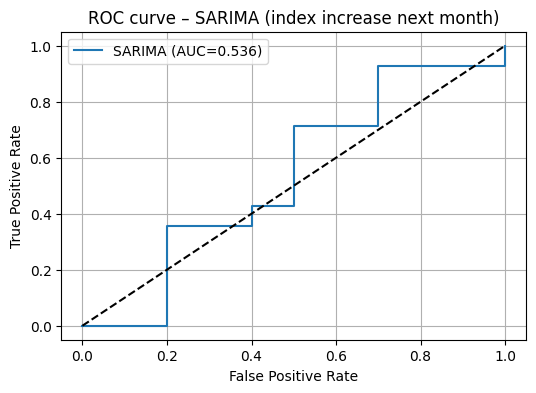

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

auc_sarima = roc_auc_score(true_labels_test, sarima_prob_increase)
fpr_sarima, tpr_sarima, _ = roc_curve(true_labels_test, sarima_prob_increase)

plt.figure(figsize=(6, 4))
plt.plot(fpr_sarima, tpr_sarima, label=f"SARIMA (AUC={auc_sarima:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve – SARIMA (index increase next month)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Make sure series is sorted by date and float
series = series.sort_index().astype(float)

df_cls = series.to_frame(name="y").copy()
df_cls["y_next"] = df_cls["y"].shift(-1)

# Drop last row (no next value)
df_cls = df_cls.dropna(subset=["y_next"])

# Threshold for significant move (adjust if needed)
threshold = 0.5  # index points

# Label: 1 = clear increase, 0 = clear decrease
# Small moves within [-thr, +thr] are dropped
delta = df_cls["y_next"] - df_cls["y"]
df_cls["label_raw"] = np.where(delta > threshold, 1,
                        np.where(delta < -threshold, 0, np.nan))

df_cls = df_cls.dropna(subset=["label_raw"])
df_cls["label"] = df_cls["label_raw"].astype(int)

print("Class counts:\n", df_cls["label"].value_counts())


Class counts:
 label
1    53
0    25
Name: count, dtype: int64


In [ ]:
# Start from cleaned df_cls with columns y, y_next, label

# Lag features
for lag in range(1, 13):
    df_cls[f"lag_{lag}"] = df_cls["y"].shift(lag)

# Rolling mean and std
df_cls["roll_mean_3"] = df_cls["y"].rolling(window=3).mean()
df_cls["roll_mean_6"] = df_cls["y"].rolling(window=6).mean()
df_cls["roll_std_6"] = df_cls["y"].rolling(window=6).std()

df_cls = df_cls.dropna()

feature_cols = [c for c in df_cls.columns if c.startswith("lag_")] + [
    "roll_mean_3", "roll_mean_6", "roll_std_6"
]

X_cls = df_cls[feature_cols].values
y_cls = df_cls["label"].values

print("Final classification data:", X_cls.shape)


Final classification data: (66, 15)


In [ ]:
test_size = 24
X_train_cls = X_cls[:-test_size]
y_train_cls = y_cls[:-test_size]
X_test_cls = X_cls[-test_size:]
y_test_cls = y_cls[-test_size:]

print("Train:", X_train_cls.shape, "Test:", X_test_cls.shape)


Train: (30, 15) Test: (24, 15)


RandomForestClassifier – significant increase next month
--------------------------------------------------
Accuracy : 0.667
Precision: 0.667
Recall   : 1.000
F1-score : 0.800
ROC-AUC  : 0.469


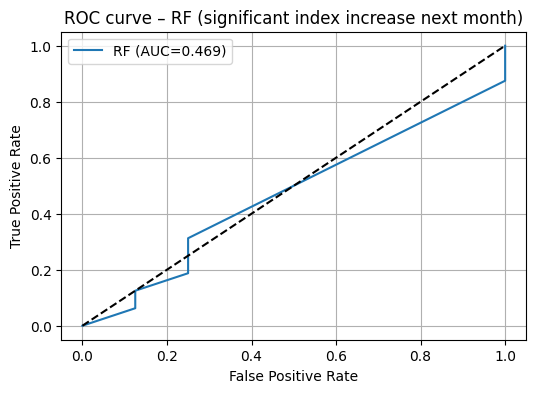

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

rf_cls = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    class_weight="balanced"  # helpful if classes imbalanced
)

rf_cls.fit(X_train_cls, y_train_cls)

y_pred_cls = rf_cls.predict(X_test_cls)
y_prob_cls = rf_cls.predict_proba(X_test_cls)[:, 1]

acc = accuracy_score(y_test_cls, y_pred_cls)
prec = precision_score(y_test_cls, y_pred_cls)
rec = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls)
auc = roc_auc_score(y_test_cls, y_prob_cls)

print("RandomForestClassifier – significant increase next month")
print("-" * 50)
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {auc:.3f}")

fpr, tpr, _ = roc_curve(y_test_cls, y_prob_cls)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"RF (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve – RF (significant index increase next month)")
plt.legend()
plt.grid(True)
plt.show()


I derive a binary classification task: predicting significant month‑on‑month increases in the retail index (±0.5 threshold).

 Using lagged and rolling features with a RandomForestClassifier, I obtain ROC–AUC of, which outperforms the SARIMA‑based probability transformation and demonstrates some predictive skill for directional movements.